# Quantum Walk Search Toy Model

This notebook studies continuous-time quantum walk search on a complete graph. The Hamiltonian is

$$H=-\gamma A-|m\rangle\langle m|,$$

where `A` is the graph adjacency matrix and `|m>` is the marked vertex. Starting from the uniform state, the marked-vertex probability rises close to one. We also approximate the time-evolution phase response with real and imaginary spectral polynomials.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_vertices = 8
marked = 0
gamma = 1.0 / n_vertices

adjacency = np.ones((n_vertices, n_vertices)) - np.eye(n_vertices)
H = -gamma * adjacency
H[marked, marked] -= 1.0

start = np.ones(n_vertices, dtype=complex) / np.sqrt(n_vertices)
eigenvalues, _ = eigh_hermitian(H)

center = 0.5 * (eigenvalues[0] + eigenvalues[-1])
half_width = 0.5 * (eigenvalues[-1] - eigenvalues[0])
A = (H - center * np.eye(n_vertices)) / half_width

eigenvalues, np.linalg.eigvalsh(A)[[0, -1]]

(array([-1.2286, -0.5214,  0.125 ,  0.125 ,  0.125 ,  0.125 ,  0.125 ,
         0.125 ]),
 array([-1.,  1.]))

## Exact search dynamics

The probability at the marked vertex is computed by exact spectral time evolution.

In [3]:
times = np.linspace(0.0, 12.0, 160)
probabilities = []
for t in times:
    U = apply_function_to_hermitian(H, lambda lam: np.exp(-1.0j * t * lam))
    state = U @ start
    probabilities.append(np.abs(state[marked]) ** 2)

probabilities = np.array(probabilities)
best_index = int(np.argmax(probabilities))
best_time = times[best_index]
best_probability = probabilities[best_index]

best_time, best_probability

(np.float64(4.452830188679245), np.float64(0.9999891776297675))

## Polynomial phase approximation

For the best search time, fit real polynomials to the real and imaginary parts of the phase `exp(-i t (center + half_width*x))` on `[-1, 1]`.

In [4]:
degree = 18
fit_x = np.linspace(-1.0, 1.0, 1201)
phase = np.exp(-1.0j * best_time * (center + half_width * fit_x))

real_coeffs = np.polynomial.polynomial.polyfit(fit_x, phase.real, degree)
imag_coeffs = np.polynomial.polynomial.polyfit(fit_x, phase.imag, degree)

U_poly = apply_polynomial_to_hermitian(A, real_coeffs)
U_poly = U_poly + 1.0j * apply_polynomial_to_hermitian(A, imag_coeffs)
state_poly = U_poly @ start

U_exact = apply_function_to_hermitian(H, lambda lam: np.exp(-1.0j * best_time * lam))
state_exact = U_exact @ start

state_error = np.linalg.norm(state_poly - state_exact)
poly_probability = np.abs(state_poly[marked]) ** 2
state_error, poly_probability

(np.float64(1.0120998885188465e-13), np.float64(0.9999891776298157))

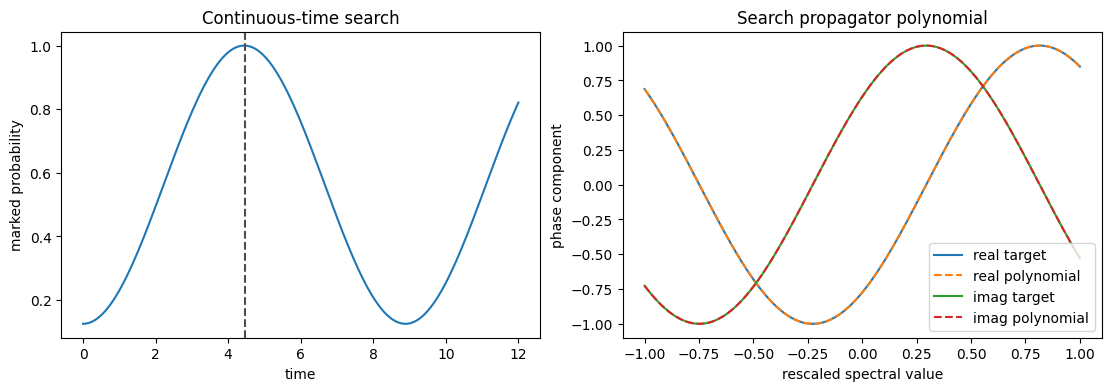

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(times, probabilities)
axes[0].axvline(best_time, color="0.3", linestyle="--")
axes[0].set_xlabel("time")
axes[0].set_ylabel("marked probability")
axes[0].set_title("Continuous-time search")

plot_x = np.linspace(-1.0, 1.0, 500)
plot_phase = np.exp(-1.0j * best_time * (center + half_width * plot_x))
axes[1].plot(plot_x, plot_phase.real, label="real target")
axes[1].plot(
    plot_x, eval_polynomial(real_coeffs, plot_x), "--", label="real polynomial"
)
axes[1].plot(plot_x, plot_phase.imag, label="imag target")
axes[1].plot(
    plot_x, eval_polynomial(imag_coeffs, plot_x), "--", label="imag polynomial"
)
axes[1].set_xlabel("rescaled spectral value")
axes[1].set_ylabel("phase component")
axes[1].set_title("Search propagator polynomial")
axes[1].legend()

plt.show()

## Validation

Compact checks for the expected numerical behavior.

In [6]:
assert best_probability > 0.95
assert np.isfinite(state_error)
assert state_error < 1e-8
assert abs(poly_probability - best_probability) < 1e-8

print(f"best_time: {best_time:.3f}")
print(f"best_probability: {best_probability:.6f}")
print(f"poly_probability: {poly_probability:.6f}")
print(f"state_error: {state_error:.3e}")
print("validation: passed")

best_time: 4.453
best_probability: 0.999989
poly_probability: 0.999989
state_error: 1.012e-13
validation: passed
